In [30]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime
%matplotlib inline

[*********************100%***********************]  1 of 1 completed

Price           Close  Short SMA   Long SMA Signal Order
Ticker           AAPL                                   
Date                                                    
2013-12-20  17.013300  16.798044  14.434809      1   0.0
2013-12-23  17.666229  16.849206  14.456572      1   0.0
2013-12-24  17.591238  16.899428  14.479396      1   0.0
2013-12-26  17.474409  16.944764  14.501647      1   0.0
2013-12-27  17.356340  16.985524  14.522678      1   0.0
...               ...        ...        ...    ...   ...
2016-09-26  25.860098  25.055753  23.174820      1   0.0
2016-09-27  25.908211  25.083320  23.173520      1   0.0
2016-09-28  26.105230  25.118219  23.176572      1   0.0
2016-09-29  25.699734  25.140823  23.178386      1   0.0
2016-09-30  25.899042  25.171139  23.183437      1   0.0

[700 rows x 5 columns]


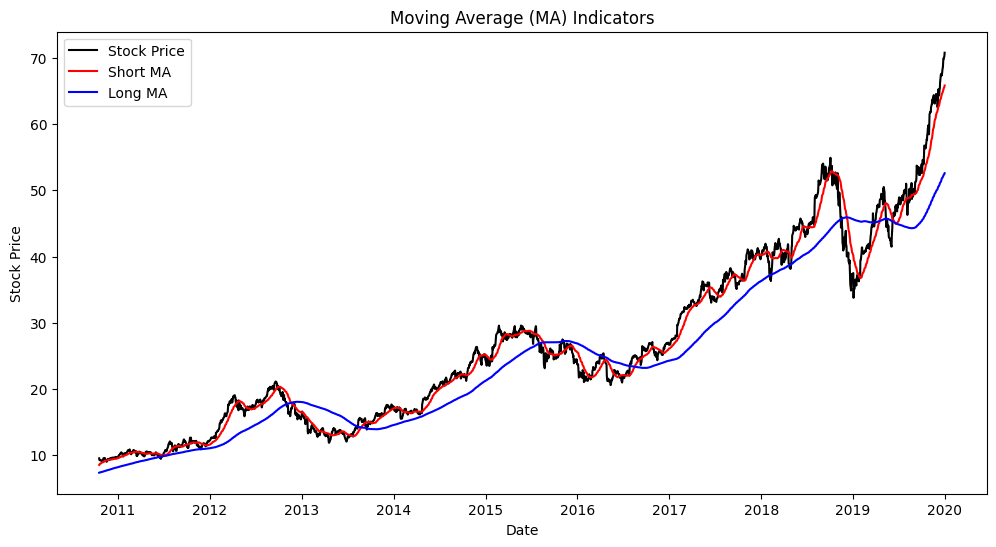

In [ ]:
# simple moving average indcator

def download_data(stock, start_date, end_date):
    ticker = yf.download(stock, start_date, end_date)
    return pd.DataFrame(ticker)

def construct_signals(data, short_period, long_period):
    data['Short SMA'] = data['Close'].rolling(window = short_period).mean()
    data['Long SMA'] = data['Close'].rolling(window = long_period).mean()
    data = data.dropna()
    return data[['Close', 'Short SMA', 'Long SMA']]

def plot_data(data):
    plt.figure(figsize=(12,6))
    plt.plot(data['Close'], label = 'Stock Price', c='k')
    plt.plot(data['Short SMA'], label = 'Short MA', c='r')
    plt.plot(data['Long SMA'], label = 'Long MA', c='b')
    plt.title('Moving Average (MA) Indicators')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()

def generate_signals(data):
    data['Signal'] = (data['Short SMA'] > data['Long SMA']).astype(int)
    data['Order'] = data['Signal'].diff()
    return data

if __name__ == '__main__':
    start = datetime.datetime(2010,1,1)
    end = datetime.datetime(2020,1,1)

    stock_data = download_data('AAPL', start, end)
    SMA = construct_signals(stock_data, 30, 200)
    plot_data(SMA)
    print(pd.DataFrame(generate_signals(SMA)))

[*********************100%***********************]  1 of 1 completed


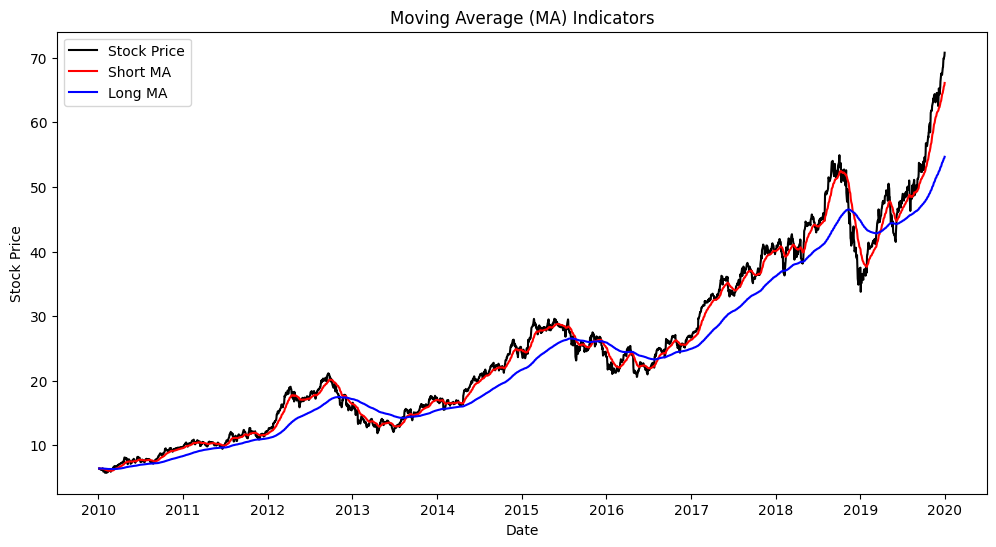

In [47]:
# Exponentially weighted moving average indicator

def construct_signals_ewma(data, short_period, long_period):
    data['Short SMA'] = data['Close'].ewm(span = short_period, adjust=False).mean()
    data['Long SMA'] = data['Close'].ewm(span = long_period, adjust=False).mean()
    data = data.dropna()
    return data[['Close', 'Short SMA', 'Long SMA']]

def plot_data_ewma(data):
    plt.figure(figsize=(12,6))
    plt.plot(data['Close'], label = 'Stock Price', c='k')
    plt.plot(data['Short EMA'], label = 'Short EMA', c='r')
    plt.plot(data['Long EMA'], label = 'Long EMA', c='b')
    plt.title('Moving Average (MA) Indicators')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()

if __name__ == '__main__':
    start = datetime.datetime(2010,1,1)
    end = datetime.datetime(2020,1,1)

    stock_data = download_data('AAPL', start, end)
    EMA = construct_signals_ewma(stock_data, 30, 200)
    plot_data(EMA)
    # print(pd.DataFrame(generate_signals(SMA)))